# ex01 Python で画像をいじってみよう

## 1. これは何？

これは，Jupyter Notebook と呼ばれる形式の文書です．
文章と Python のコードを一緒に書いて，コードを実行することができます．

この notebook 上では，文章やコードは，「セル」というかたまりでできています．
セルにマウスカーソルを置いてクリックすると，そのセルを選択することができます．
試しに，↓の Python コードが書かれたセルを選択して，セルの左の方にある三角形のボタン（$\triangleright$，再生ボタンみたいなの）を押してみましょう．

In [ ]:
x = 4648
y = 1
print(x + y)

コードの書かれたセル（コードセル）のボタンを押すと，そのコードが実行されます．
もう一度↑のコードセルを選んで，`y = 1` を `y = 1315` に書きかえてから実行してみましょう．
ボタンを押す代わりに，Shift キーを押しながら Enter/Return キーを押しても実行できます．

## 2. 準備

次の2つのコードセルを実行しましょう．ただし，実行しても何も出力されません．
これらは，あとで出てくるコードを実行するために必要な準備を行っています．


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# notebook 上で OpenCV の画像を表示するための関数
#
def display(img, axisoff=False):
    img2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img2)
    if axisoff:
        plt.axis('off')
    plt.show()

## 3. 画像を読み込んで加工しよう Step1

このセクションのゴールは次の2点です： 
- Jupyter Notebook のセルを実行して，Python のプログラムを少しずつ動かす方法に慣れる．
- 画像ファイルを読み込んで，画面に表示できるようになる．

次のセルを実行すると，画像ファイルを読み込んで，notebook 上に表示します．

(120, 170, 3)


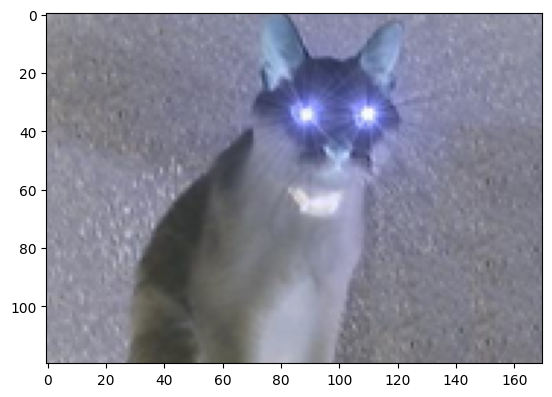

In [3]:
# blackuni3.png というファイル名の画像を読み込んで，変数 cat0 にその画素値を格納
cat0 = cv2.imread('blackuni3.png')

# cat0 の shape （形）を表示
print(cat0.shape)

# cat0 を表示
display(cat0)

セルを実行した結果，画像を表す数値（画素値）が `cat0` という変数に代入されました．
この画像は，幅が 170 画素，高さが 120 画素のカラー画像です．

次のセルを実行してみましょう．

`cat1 = cv2.flip(cat0, 1)` という行を実行すると，`cat0` に格納された画像を左右反転させたものを作り，それを `cat1` に代入してくれます．

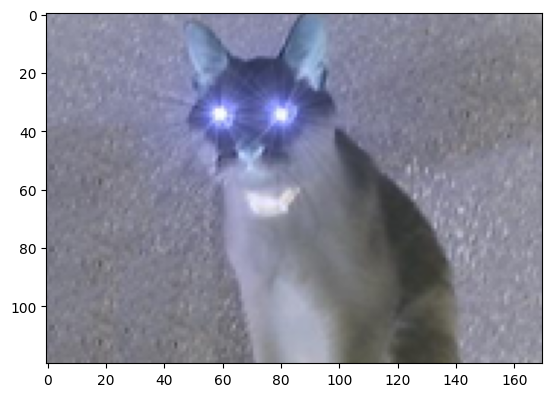

In [4]:
# cat0 が表す画像の左右を反転した画像を cat1 とする
cat1 = cv2.flip(cat0, 1)
display(cat1)

---
**★ やってみよう (1)**

ウェブブラウザで `opencv flip` や `cv2.flip` とキーワードを指定して検索すると，`cv2.flip` 関数の使い方の情報が出てきます．
上の例では2番目の引数を `1` にしていますが，この数字を変えると，画像を上下に反転させたり，両方とも（上下左右に）反転させたりできます．
どう変えるとどうなるかを調べて，↑のセルの `cv2.flip` の括弧の中を書きかえて実行してみましょう．

---

次は，画像に長方形を描いてみましょう．
`cv2.rectangle` 関数でできます．

`cv2.flip` は，引数で渡された画像を反転させたものを別の画像として返してくれましたが，`cv2.rectangle` は，引数で渡された画像を直接いじります．


In [ ]:
# 画像を読み込んで cat0 とする
cat0 = cv2.imread('blackuni3.png')

# cat0 に長方形を描く． (20, 60) と (60, 80) を2つの頂点とする長方形を，青色で，線の太さ 1 で
cv2.rectangle(cat0, (20, 60), (60, 80), (255, 0, 0), thickness=1)

# 重ねて長方形を描く．青色で，thickness を負にすると塗りつぶす
cv2.rectangle(cat0, (160, 80), (120, 200), (255, 0, 0), thickness=-1)

# cat0 を表示
display(cat0)

引数に `(20, 60)` などといろいろ指定しています．
それらの意味は，コードセルに書いたコメントと，↑の実行結果から考えてみましょう．
ちゃんと調べるなら，`cv2.rectangle` でウェブ検索してみるとよいでしょう．

ちなみに，図についた縦横の軸の目盛から分かるとおり，y軸（縦方向）は数学でよく見るのとは向きが逆なので，座標の値も下の方が大きいことに注意してください．

---
**★ やってみよう (2)**

<img src="./rectangles.png" width=500>

以下のコードの中身を書きかえて，↑の画像を再現してみましょう．

色をあわらす数値は，(<font color="0000ff">青</font>の強さ, <font color="00ff00">緑</font>の強さ, <font color="ff0000">赤</font>の強さ) という3つの組です．
それぞれの色の強さは 0 から 255 まで（256段階）で，大きいほどその色をたくさん含みます．

`(255, 0, 0)` は真っ青，`(255, 255, 255)` は真っ白，`(255, 255, 0)` は青と緑を最大含む色（どんな色？）

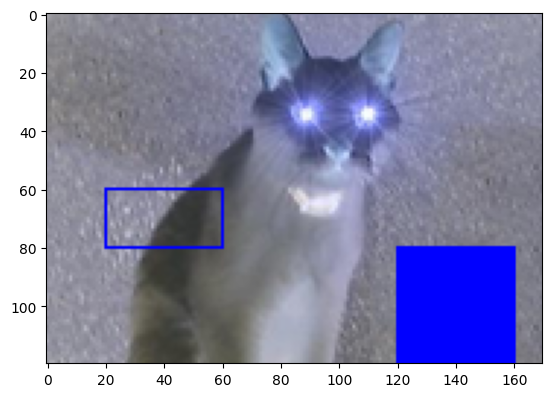

In [5]:
# このセルを修正して，↑の画像を再現しよう
cat0 = cv2.imread('blackuni3.png')
cv2.rectangle(cat0, (20, 60), (60, 80), (255, 0, 0), thickness=1)
cv2.rectangle(cat0, (160, 80), (120, 200), (255, 0, 0), thickness=-1)
display(cat0)

---

次のセルを実行するとどんな画像になるか，まずはやってみましょう．

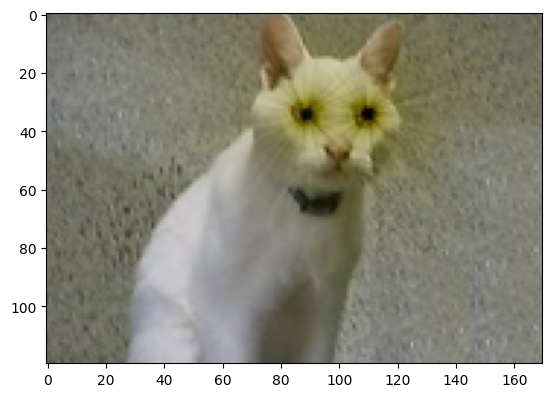

In [6]:
# 画像を読み込んで cat0 とする
cat0 = cv2.imread('blackuni3.png')

# cat0 の画素値を全て反転させたものを cat1 とする
cat1 = 255 - cat0

# cat1 を表示
display(cat1)

`cat1 = 255 - cat0` という計算では，色を表す数値の最大値である 255 から `cat0` の画素値を引いたものが `cat1` の画素値になります．
何が起こっているのか理解するために，黒，白，赤，緑，黄，に対応する画素値で考えてみましょう．

- 黒<font color="000000">■</font>: `(0, 0, 0)` は `(255, 255, 255)` つまり白<font color="ffffff">■</font>になる
- 白<font color="ffffff">■</font>: `(255, 255, 255)` は `(0, 0, 0)` つまり黒<font color="000000">■</font>になる
- 赤<font color="ff0000">■</font>: `(0, 0, 255)` は `(255, 255, 0)` つまりシアン<font color="00ffff">■</font>（青と緑を最大含む色）になる
- 緑<font color="00ff00">■</font>: `(0, 255, 0)` は `(255, 0, 255)` つまりマゼンタ<font color="ff00ff">■</font>（青と赤を最大含む色）になる
- 黄<font color="ffff00">■</font>: `(0, 255, 255)` は `(255, 0, 0)` つまり青<font color="0000ff">■</font>になる

このように，「色を表す数値の最大値である 255 から元の画素値を引いたもの」は，元の画像の画素値の大小を反転させたものとなります．

---
**★ やってみよう (3)**

`cv2.circle` で円を描くことができます．描画の関数は他にもあります．使い方を調べて，次のセルをいじっていろいろ試してみよう．


In [ ]:
cat0 = cv2.imread('blackuni3.png')
display(cat0)

---

## 4. 画像を読み込んで加工しよう Step2

このセクションのゴールは次の2点です： 
- 画像が，たくさんの小さな点（画素）からできていることを確認する．
- 画素の値を変えることで，画像の一部の色や明るさを変えられることを体験する．

次は，画像の一部の範囲を切り取って，そこを加工してみましょう．

まずは，画像の一部の範囲を切り取った画像を作る方法を説明します．
次のセルを実行すると，`cat0` の「y座標」が 40 から 99 まで，「x座標」が 20 から 79 までの範囲を切り取ったものが `cat1` となります．
`40:100` という指定が 40 以上 100 **未満** の範囲を表し，`20:80` が 20 以上 80 **未満** の範囲を表します．
`:` だけの所は，全ての範囲を表します（この例では，色の軸に対応しています）．

cat0.shape =  (120, 170, 3)
cat1.shape =  (60, 60, 3)


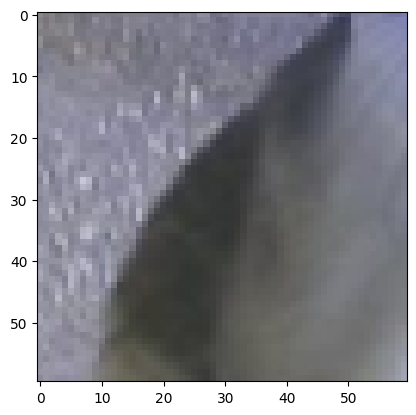

In [7]:
# 画像を読み込んで cat0 とする
cat0 = cv2.imread('blackuni3.png')

# cat0 の一部を切り取る
cat1 = cat0[40:100, 20:80, :]

# shape の表示
print('cat0.shape = ', cat0.shape)
print('cat1.shape = ', cat1.shape)

# 表示
display(cat1)

`a:b` のようにして画像の特定範囲を指定できることが分かりました．
範囲を指定して，そこに色を表す3つの数値を代入すると，その範囲をその色で塗りつぶすことになります．

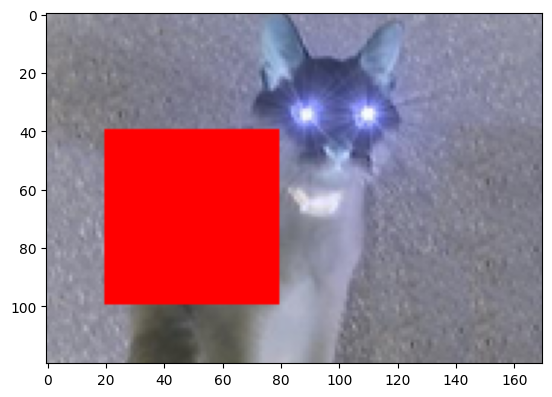

In [8]:
# 画像を読み込んで cat0 とする
cat0 = cv2.imread('blackuni3.png')

# cat0 の一部の範囲に赤色の画素値を代入
cat0[40:100, 20:80, :] = [0, 0, 255]

# 表示
display(cat0)

---
**★ やってみよう (4)**

次のコードセルを修正して，猫の顔を青く塗りつぶしてみましょう．
`cv2.rectangle` でもできますが，ここでは上で説明した範囲指定の方法でやってみてね．


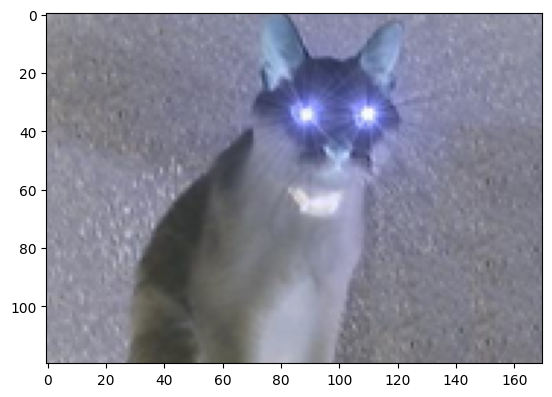

In [9]:
cat0 = cv2.imread('blackuni3.png')
display(cat0)

---

次のセルが何をやっているのか，実行して＆コードを読んで理解しましょう．

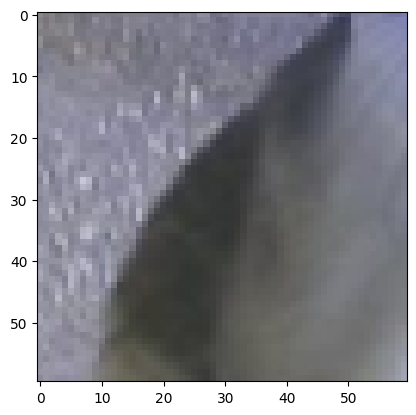

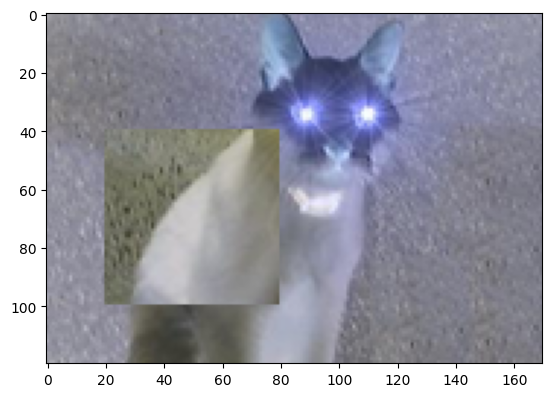

In [10]:
# 画像を読み込んで cat0 とする
cat0 = cv2.imread('blackuni3.png')

# cat0 の一部を切り取ったものを cat1 とする
cat1 = cat0[40:100, 20:80, :]

# cat1 を表示
display(cat1)

# cat1 の画素値を反転したものを cat0 の元の範囲に代入する
cat0[40:100, 20:80, :] = 255 - cat1

# cat0 を表示
display(cat0)

---
**★ やってみよう (5)**

ネコの顔の部分の画素値を反転させた画像を作ってみよう．

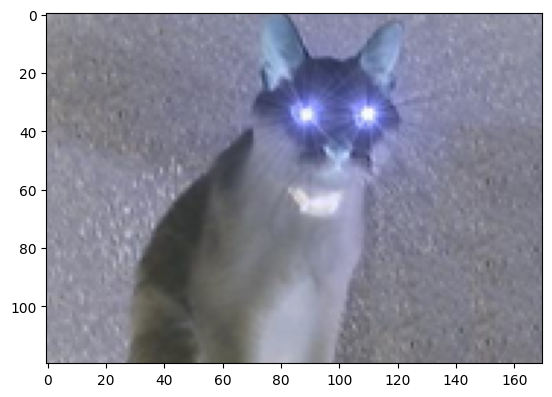

In [11]:
cat0 = cv2.imread('blackuni3.png')
display(cat0)

---

範囲を指定して切り取った画像を，`cv2.flip`等の関数を使って加工することもできます．

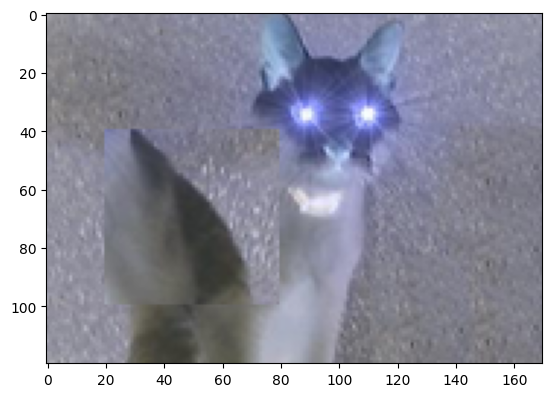

In [12]:
# 画像を読み込んで cat0 とする
cat0 = cv2.imread('blackuni3.png')

# cat0 の一部を切り取ったものを cat1 とする
cat1 = cat0[40:100, 20:80, :]

# cat1 の左右を反転したものを cat0 の元の範囲に代入する
cat0[40:100, 20:80, :] = cv2.flip(cat1, 1)

# cat0 を表示
display(cat0)

---
**★ やってみよう (6)**

ネコの顔の部分を上下に反転させた画像を作ってみよう．

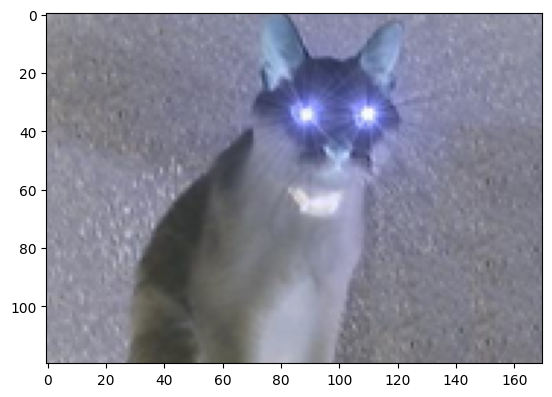

In [13]:
cat0 = cv2.imread('blackuni3.png')
display(cat0)

---